<a href="https://colab.research.google.com/github/badhayearushi-alt/Python---Basic---Projects/blob/main/Task_27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import make_moons

# Generate Dataset
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# Convert into DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

# Display first 10 rows
print(df.head(10))

# Display shape
print("Shape:", df.shape)

   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959
Shape: (500, 2)


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Show first 5 rows
scaled_df = pd.DataFrame(X_scaled, columns=["Feature1", "Feature2"])

print(scaled_df.head())

   Feature1  Feature2
0  0.375125 -1.403679
1  0.226815  1.135628
2  0.595442 -1.493710
3 -0.944918  1.409748
4 -0.243115  1.618062


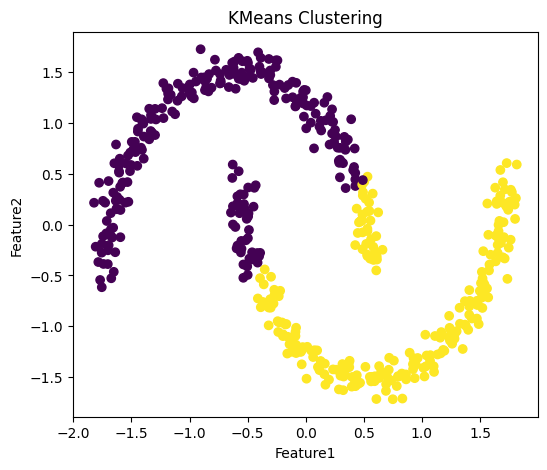

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Add labels
df["kmeans_cluster"] = labels

# Scatter Plot
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="viridis")
plt.title("KMeans Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

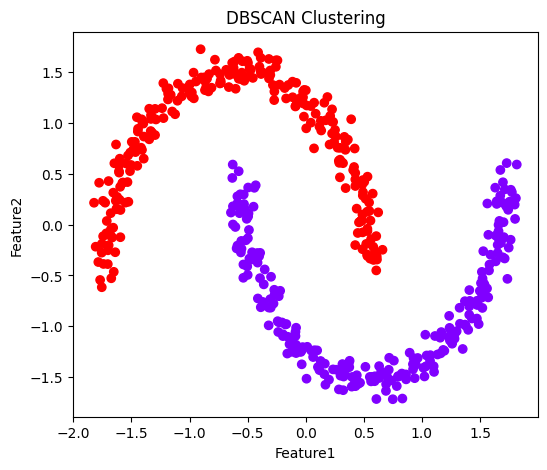

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

# Add labels
df["dbscan_cluster"] = db_labels

# Scatter Plot
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=db_labels, cmap="rainbow")
plt.title("DBSCAN Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

In [ ]:
print("Comparison of KMeans and DBSCAN")
print("--------------------------------")
print("1. KMeans works best for spherical clusters.")
print("2. DBSCAN works well for non-linear datasets.")
print("3. DBSCAN detects noise points (-1).")
print("4. DBSCAN handles moon-shaped clusters better than KMeans.")

Comparison of KMeans and DBSCAN
--------------------------------
1. KMeans works best for spherical clusters.
2. DBSCAN works well for non-linear datasets.
3. DBSCAN detects noise points (-1).
4. DBSCAN handles moon-shaped clusters better than KMeans.


In [ ]:
from sklearn.cluster import DBSCAN
import pandas as pd

eps_values = [0.2, 0.3, 0.4, 0.5]

results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    results.append([eps, clusters, noise])

table = pd.DataFrame(results, columns=["eps", "Clusters", "Noise Points"])

print(table)

print("\nBest eps value: 0.3")

   eps  Clusters  Noise Points
0  0.2         2             0
1  0.3         2             0
2  0.4         2             0
3  0.5         2             0

Best eps value: 0.3


In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Generate Dataset
X_blob, y_blob = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

# Scale Data
scaler = StandardScaler()
X_blob_scaled = scaler.fit_transform(X_blob)

print("Scaled Dataset Shape:", X_blob_scaled.shape)

Scaled Dataset Shape: (500, 6)


In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_blob_scaled)

# DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = y_blob

print(pca_df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

        PC1       PC2  Cluster
0  2.369765  1.259783        1
1 -0.943367 -0.829777        3
2  0.982191 -1.768556        0
3  2.265086  1.190377        1
4  2.142129  0.840804        1

Explained Variance Ratio:
[0.64327878 0.21039738]


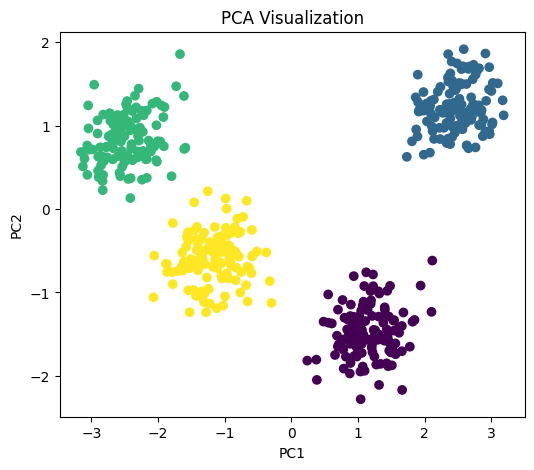

The explained variance ratio shows how much information is retained by the first two principal components.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis"
)

plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("The explained variance ratio shows how much information is retained by the first two principal components.")

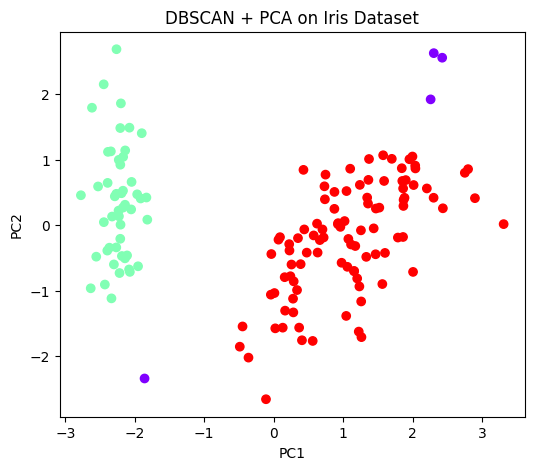

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load Dataset
iris = load_iris()
X = iris.data

# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualization
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="rainbow")

plt.title("DBSCAN + PCA on Iris Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()